# Low-Dose CT Reconstruction with Poisson Noise

This notebook demonstrates the benefit of **Penalized Weighted Least Squares (PWLS)** reconstruction for low-dose CT, where photon-counting noise follows Poisson statistics.

## Key idea

In low-dose CT, the number of detected photons per ray is small, and the noise variance depends on the signal: rays through thick/dense material receive fewer photons and have higher noise. Standard (unweighted) reconstruction treats all measurements equally, amplifying noise from unreliable low-count measurements. PWLS weights each measurement by its photon count, giving more influence to reliable measurements and suppressing noise from low-count rays.

## Contents
1. Load precomputed results
2. Visualize sinograms (clean vs noisy)
3. Compare reconstructions (unweighted vs PWLS)
4. Error analysis
5. Dose-level comparison
6. Quantitative metrics

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Setup paths
TASK_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, TASK_DIR)
DATA_DIR = os.path.join(TASK_DIR, "data")
REF_DIR = os.path.join(TASK_DIR, "evaluation", "reference_outputs")

## 1. Load precomputed results

We load the ground truth phantom, raw sinogram data, and precomputed reconstructions from the reference outputs. This avoids re-running the SVMBIR solver (which takes a few seconds per reconstruction).

In [2]:
from src.preprocessing import load_ground_truth, load_raw_data, load_metadata
from src.visualization import compute_ncc, compute_nrmse, centre_crop

# Load data
phantom = load_ground_truth(DATA_DIR)
raw = load_raw_data(DATA_DIR)
meta = load_metadata(DATA_DIR)

sino_clean = raw["sinogram_clean"]
sino_low = raw["sinogram_low_dose"]
sino_high = raw["sinogram_high_dose"]
weights_low = raw["weights_low_dose"]
angles = raw["angles"]

# Load precomputed reconstructions
ref = np.load(os.path.join(REF_DIR, "reconstructions.npz"))
recon_uw = ref["recon_unweighted"][0]      # unweighted, low-dose
recon_pwls_low = ref["recon_pwls_low"][0]  # PWLS, low-dose
recon_pwls_high = ref["recon_pwls_high"][0]  # PWLS, high-dose

# Load metrics
with open(os.path.join(TASK_DIR, "evaluation", "metrics.json")) as f:
    metrics = json.load(f)

print(f"Phantom shape: {phantom.shape}, range: [{phantom.min():.4f}, {phantom.max():.4f}]")
print(f"Sinogram shape: {sino_low.shape} (views x channels)")
print(f"Low-dose I0 = {meta['I0_low_dose']}, High-dose I0 = {meta['I0_high_dose']}")

Phantom shape: (256, 256), range: [0.0000, 0.0400]
Sinogram shape: (256, 367) (views x channels)
Low-dose I0 = 1000, High-dose I0 = 50000


## 2. Sinogram comparison

The Poisson noise model generates signal-dependent noise: regions with higher attenuation (thicker material path) receive fewer photons and therefore have noisier measurements. Compare the clean sinogram with the low-dose and high-dose noisy versions.

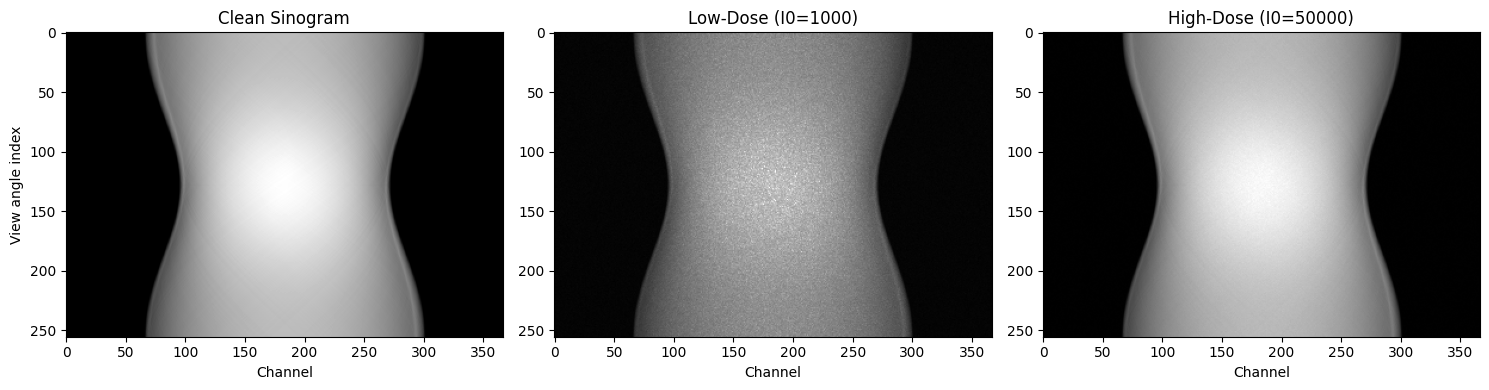

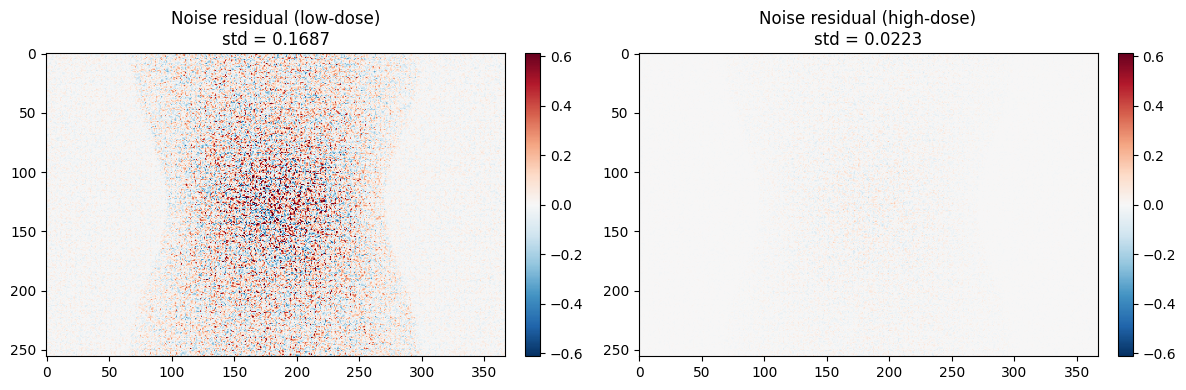

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(sino_clean, aspect="auto", cmap="gray")
axes[0].set_title("Clean Sinogram")
axes[0].set_xlabel("Channel"); axes[0].set_ylabel("View angle index")

axes[1].imshow(sino_low, aspect="auto", cmap="gray")
axes[1].set_title(f"Low-Dose (I0={meta['I0_low_dose']})")
axes[1].set_xlabel("Channel")

axes[2].imshow(sino_high, aspect="auto", cmap="gray")
axes[2].set_title(f"High-Dose (I0={meta['I0_high_dose']})")
axes[2].set_xlabel("Channel")

plt.tight_layout()
plt.show()

# Show noise residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
noise_low = sino_low - sino_clean
noise_high = raw["sinogram_high_dose"] - sino_clean
vmax_n = np.percentile(np.abs(noise_low), 99)

im0 = axes[0].imshow(noise_low, aspect="auto", cmap="RdBu_r", vmin=-vmax_n, vmax=vmax_n)
axes[0].set_title(f"Noise residual (low-dose)\nstd = {noise_low.std():.4f}")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(noise_high, aspect="auto", cmap="RdBu_r", vmin=-vmax_n, vmax=vmax_n)
axes[1].set_title(f"Noise residual (high-dose)\nstd = {noise_high.std():.4f}")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 3. Reconstruction comparison: Unweighted vs PWLS

The key comparison: both methods use the same SVMBIR solver with identical regularization parameters. The only difference is the data weighting:

- **Unweighted**: all sinogram measurements treated equally ($W = I$)
- **PWLS**: each measurement weighted by its photon count ($w_i = I_i$), so noisy low-count measurements contribute less

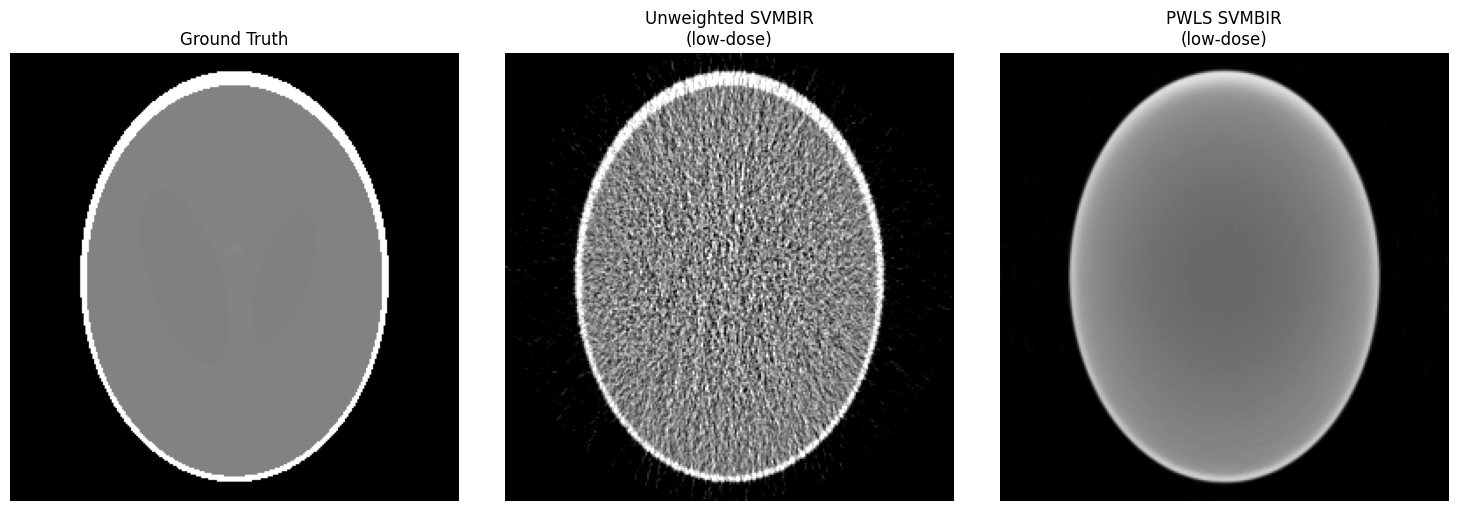

In [4]:
vmin, vmax = phantom.min(), phantom.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(phantom, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(recon_uw, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("Unweighted SVMBIR\n(low-dose)")
axes[1].axis("off")

axes[2].imshow(recon_pwls_low, cmap="gray", vmin=vmin, vmax=vmax)
axes[2].set_title("PWLS SVMBIR\n(low-dose)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4. Error maps

Absolute error maps show where each method deviates from the ground truth. PWLS should show smaller errors overall, especially in regions behind thick attenuating structures where Poisson noise is worst.

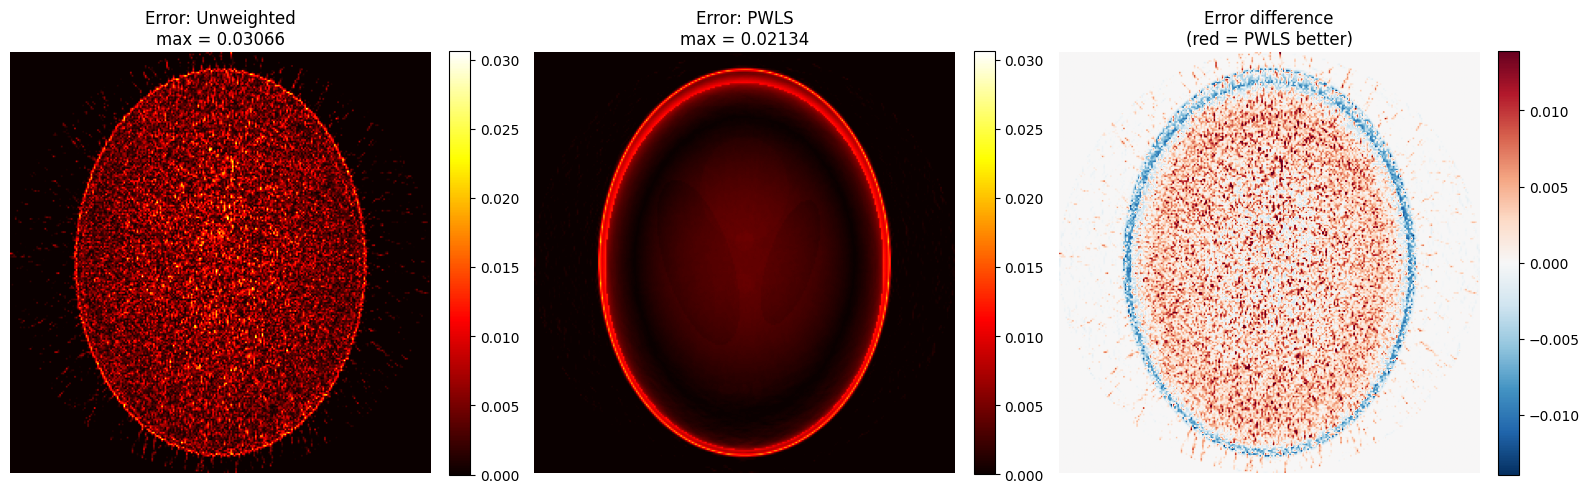

In [5]:
err_uw = np.abs(recon_uw - phantom)
err_pwls = np.abs(recon_pwls_low - phantom)
vmax_err = max(err_uw.max(), err_pwls.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(err_uw, cmap="hot", vmin=0, vmax=vmax_err)
axes[0].set_title(f"Error: Unweighted\nmax = {err_uw.max():.5f}")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(err_pwls, cmap="hot", vmin=0, vmax=vmax_err)
axes[1].set_title(f"Error: PWLS\nmax = {err_pwls.max():.5f}")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Difference of errors (positive = PWLS is better)
err_diff = err_uw - err_pwls
vmax_d = np.percentile(np.abs(err_diff), 99)
im2 = axes[2].imshow(err_diff, cmap="RdBu_r", vmin=-vmax_d, vmax=vmax_d)
axes[2].set_title("Error difference\n(red = PWLS better)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 5. Dose-level comparison

Comparing PWLS reconstruction quality across dose levels shows how image quality degrades as photon count decreases.

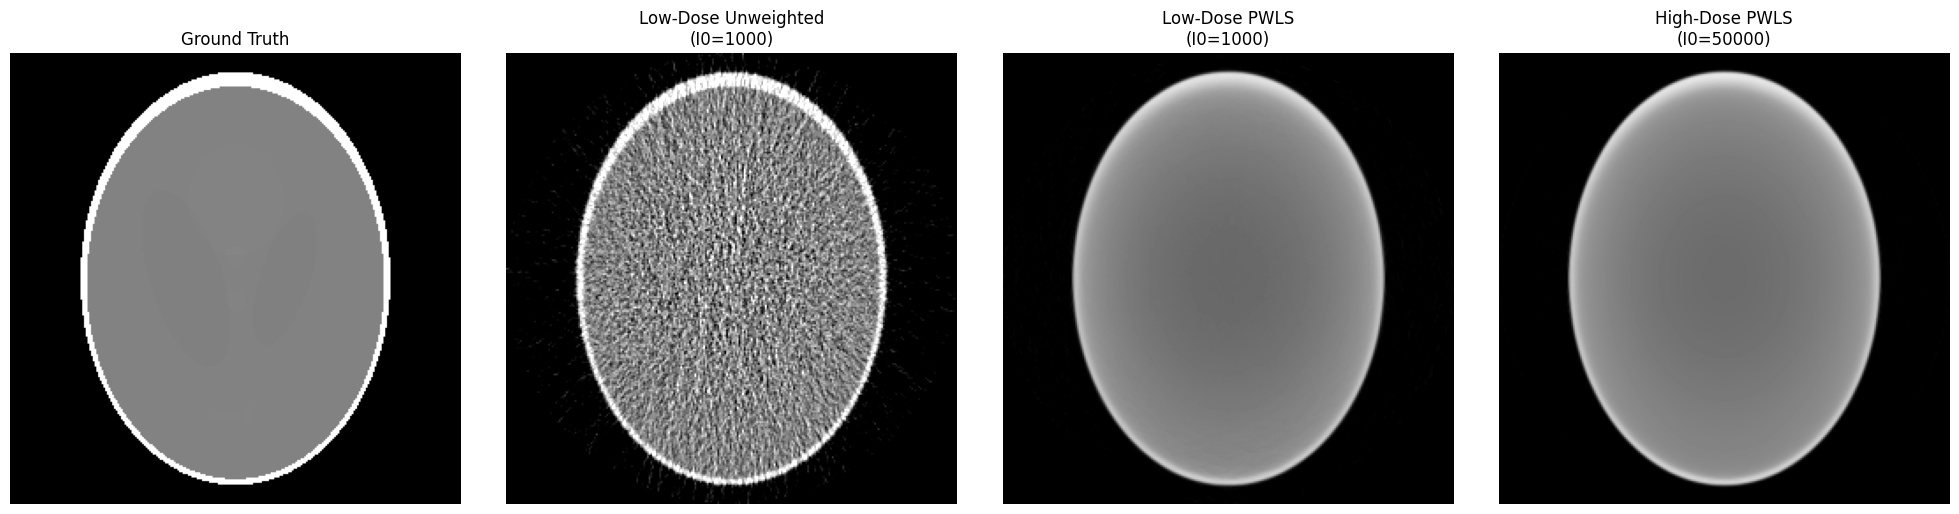

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

titles = ["Ground Truth", 
          f"Low-Dose Unweighted\n(I0={meta['I0_low_dose']})", 
          f"Low-Dose PWLS\n(I0={meta['I0_low_dose']})", 
          f"High-Dose PWLS\n(I0={meta['I0_high_dose']})"]
images = [phantom, recon_uw, recon_pwls_low, recon_pwls_high]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Quantitative metrics

NCC (normalized cross-correlation, higher is better) and NRMSE (normalized root mean squared error, lower is better) computed on the 80% centre crop.

Unweighted (low-dose)           NCC = 0.9533  NRMSE = 0.1485
PWLS (low-dose)                 NCC = 0.9854  NRMSE = 0.0851
PWLS (high-dose)                NCC = 0.9866  NRMSE = 0.0799

Evaluation boundaries:
  NCC >= 0.8868
  NRMSE <= 0.0936


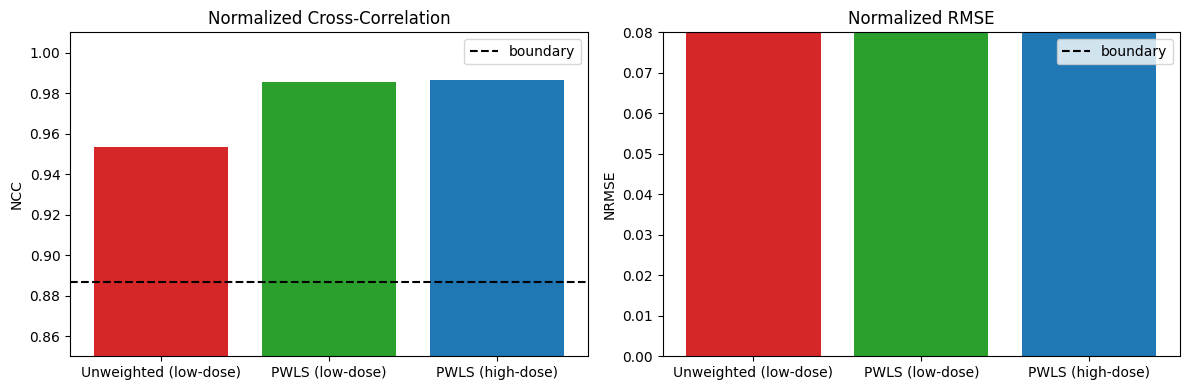

In [7]:
gt_crop = centre_crop(phantom, 0.8)

results = []
for name, recon in [("Unweighted (low-dose)", recon_uw),
                     ("PWLS (low-dose)", recon_pwls_low),
                     ("PWLS (high-dose)", recon_pwls_high)]:
    rc = centre_crop(recon, 0.8)
    ncc = compute_ncc(rc, gt_crop)
    nrmse = compute_nrmse(rc, gt_crop)
    results.append((name, ncc, nrmse))
    print(f"{name:30s}  NCC = {ncc:.4f}  NRMSE = {nrmse:.4f}")

print(f"\nEvaluation boundaries:")
print(f"  NCC >= {metrics['ncc_boundary']:.4f}")
print(f"  NRMSE <= {metrics['nrmse_boundary']:.4f}")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
names = [r[0] for r in results]
nccs = [r[1] for r in results]
nrmses = [r[2] for r in results]
colors = ["#d62728", "#2ca02c", "#1f77b4"]

ax1.bar(names, nccs, color=colors)
ax1.axhline(metrics["ncc_boundary"], color="k", linestyle="--", label="boundary")
ax1.set_ylabel("NCC")
ax1.set_title("Normalized Cross-Correlation")
ax1.set_ylim(0.85, 1.01)
ax1.legend()

ax2.bar(names, nrmses, color=colors)
ax2.axhline(metrics["nrmse_boundary"], color="k", linestyle="--", label="boundary")
ax2.set_ylabel("NRMSE")
ax2.set_title("Normalized RMSE")
ax2.set_ylim(0, 0.08)
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Poisson weight visualization

The PWLS weights are the measured photon counts. Rays passing through the center of the phantom (highest total attenuation) have the lowest weights, meaning their noisy measurements are down-weighted during reconstruction.

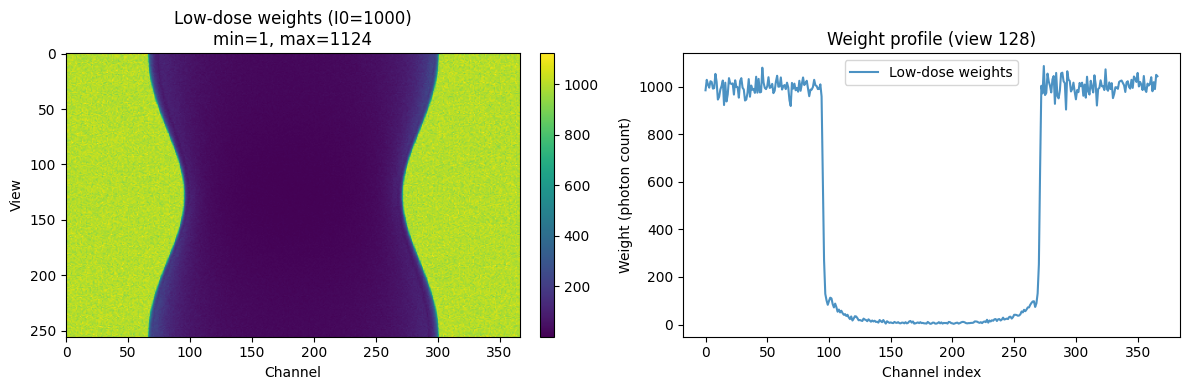

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(weights_low, aspect="auto", cmap="viridis")
axes[0].set_title(f"Low-dose weights (I0={meta['I0_low_dose']})\nmin={weights_low.min():.0f}, max={weights_low.max():.0f}")
axes[0].set_xlabel("Channel"); axes[0].set_ylabel("View")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Profile through middle view
mid_view = weights_low.shape[0] // 2
axes[1].plot(weights_low[mid_view], label="Low-dose weights", alpha=0.8)
axes[1].set_xlabel("Channel index")
axes[1].set_ylabel("Weight (photon count)")
axes[1].set_title(f"Weight profile (view {mid_view})")
axes[1].legend()

plt.tight_layout()
plt.show()

## Running from scratch (optional)

The following code runs the full pipeline from scratch using the cleaned `src/` modules. Uncomment and run to reproduce the results above.

In [9]:
# from src.solvers import svmbir_recon_unweighted, svmbir_recon_pwls
# 
# image_size = meta["image_size"]
# 
# # Unweighted baseline
# recon_uw_scratch = svmbir_recon_unweighted(
#     sino_low, angles, image_size, image_size, verbose=1)
# 
# # PWLS with Poisson weights
# recon_pwls_scratch = svmbir_recon_pwls(
#     sino_low, angles, weights_low, image_size, image_size, verbose=1)
# 
# # Verify parity
# gt_c = centre_crop(phantom, 0.8)
# print(f"Unweighted NCC = {compute_ncc(centre_crop(recon_uw_scratch, 0.8), gt_c):.4f}")
# print(f"PWLS NCC = {compute_ncc(centre_crop(recon_pwls_scratch, 0.8), gt_c):.4f}")